In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

df = pd.read_csv('Apple_Stock.csv')
df.head()

df.drop([' Volume', ' Open', ' High', ' Low'], axis=1, inplace=True)
df.head()

df.columns = df.columns.str.strip()
df.columns

df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.set_index('Date', inplace=True)


<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
C:\Users\admin\AppData\Local\Temp\ipykernel_30376\2312531832.py:18: SyntaxWarning: invalid escape sequence '\$'
  df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)


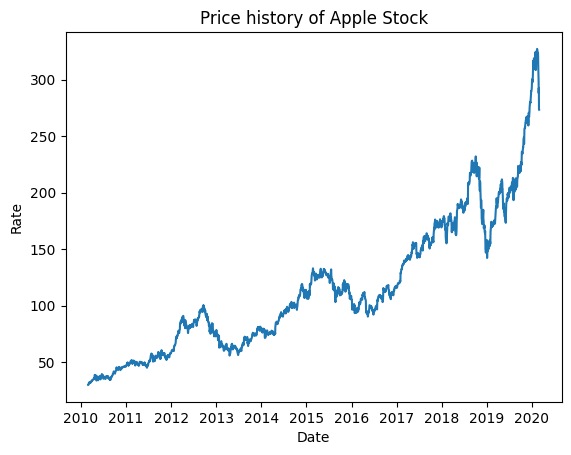

In [8]:
plt.plot(df.index, df['Close/Last'])
plt.xlabel('Date')
plt.ylabel('Rate')
plt.title('Price history of Apple Stock')
plt.show()

In [9]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t{}: {}'.format(key, value))

In [11]:
check_stationarity(df['Close/Last'])

ADF Statistic: 0.04918130127669498
p-value: 0.9624152269389331
Critical Values:
	1%: -3.432960050084045
	5%: -2.8626931078801285
	10%: -2.567383843706519


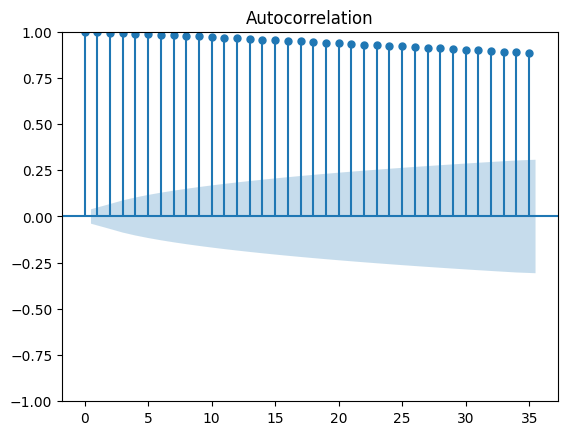

In [15]:
plot_acf(df['Close/Last'])
plt.show()

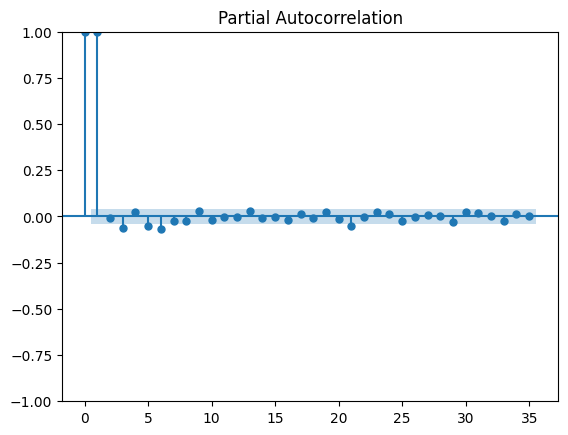

In [16]:
plot_pacf(df['Close/Last'])
plt.show()

In [17]:
sarima_model = SARIMAX(df['Close/Last'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima_model.fit()

c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [18]:
train_size = int(len(df) * 0.8)
train, test = df['Close/Last'][:train_size], df['Close/Last'][train_size:]

In [19]:
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima_model.fit()

c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [20]:
predictions = sarima_result.predict(start=len(train), end=len(train) + len(test)-1)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 37.500167626254424


c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


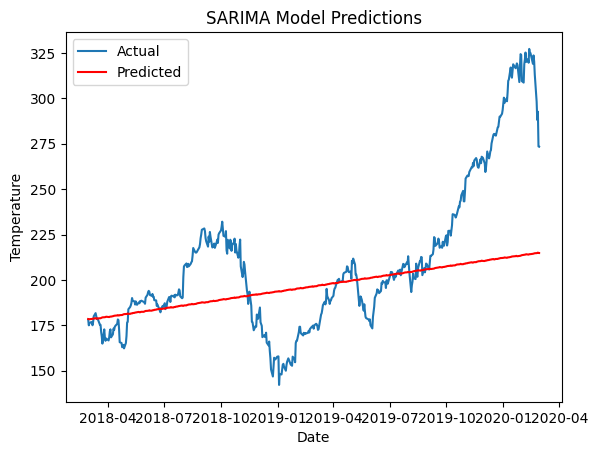

In [21]:
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, color='red', label='Predicted')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('SARIMA Model Predictions')
plt.legend()
plt.show()